<a href="https://colab.research.google.com/github/Ramdhanmaulana-del88/UTS_RAMDHAN_MAULANA_6B_BIS_14022300100/blob/main/uts_RAMDHAN_MAULANA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
pip install google-play-scraper

In [4]:
from google_play_scraper import reviews, Sort
import csv

result, _ = reviews(
    'app.bpjs.mobile',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=100,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'


with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
    writer.writeheader()
    for review in result:

        writer.writerow({
            'userName': review['userName'],
            'score': review['score'],
            'at': review['at'],
            'content': review['content']
        })

print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")

Berhasil menyimpan 100 ulasan ke 'ulasan_google_play.csv'


In [9]:
pip install transformers pandas torch

In [6]:
import pandas as pd
from transformers import pipeline

# Load the CSV file into a DataFrame
df = pd.read_csv(filename)

display(df.head())

,userName,score,at,content
0,Bos Sunawan,5,2026-05-04 17:00:27,mantul
1,Karnadi Kubil,1,2026-05-04 16:50:57,udah ribet susah masuknya lagi gmn kalo urgen
2,Anha Anha,5,2026-05-04 16:50:49,terbaik apk bosku
3,Rska Sbla,1,2026-05-04 16:25:57,"aplikasi bengakkk, dikit2 logout, pas mau logi..."
4,Lailatis Syarifah,2,2026-05-04 16:16:54,"barusan abis update. jujur ui nya lebih jelek,..."


Now, let's load the sentiment analysis model from Hugging Face and apply it to the review content.

In [7]:
# Load the sentiment analysis pipeline
sentiment_pipeline = pipeline("sentiment-analysis", model="w11wo/indonesian-roberta-base-prdect-id")

# Define a function to get sentiment and score
def get_sentiment(text):
    try:
        result = sentiment_pipeline(text)[0]
        return result['label'], result['score']
    except Exception as e:
        print(f"Error processing text: {text}. Error: {e}")
        return None, None

# Apply the sentiment analysis to the 'content' column
df[['sentiment_label', 'sentiment_score']] = df['content'].apply(lambda x: pd.Series(get_sentiment(x)))

# Display the DataFrame with sentiment analysis results
display(df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,userName,score,at,content,sentiment_label,sentiment_score
0,Bos Sunawan,5,2026-05-04 17:00:27,mantul,Happy,0.486836
1,Karnadi Kubil,1,2026-05-04 16:50:57,udah ribet susah masuknya lagi gmn kalo urgen,Sadness,0.394774
2,Anha Anha,5,2026-05-04 16:50:49,terbaik apk bosku,Happy,0.953885
3,Rska Sbla,1,2026-05-04 16:25:57,"aplikasi bengakkk, dikit2 logout, pas mau logi...",Anger,0.402075
4,Lailatis Syarifah,2,2026-05-04 16:16:54,"barusan abis update. jujur ui nya lebih jelek,...",Fear,0.549198


Let's look at the distribution of sentiment labels.

/tmp/ipykernel_21895/438260933.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment_label', palette='viridis')


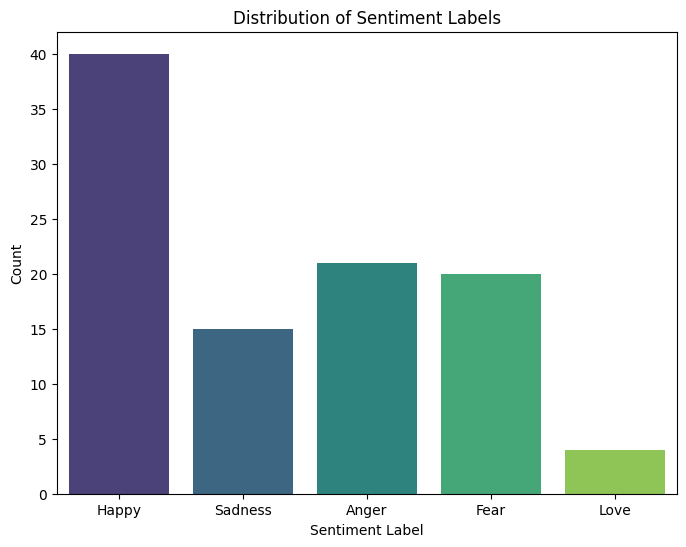

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of sentiment labels
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='sentiment_label', palette='viridis')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()